In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl
from koala.lattice import Lattice, INVALID
from koala import example_graphs as eg
from koala import pachner_moves
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle
from generate_graphs import Parameters

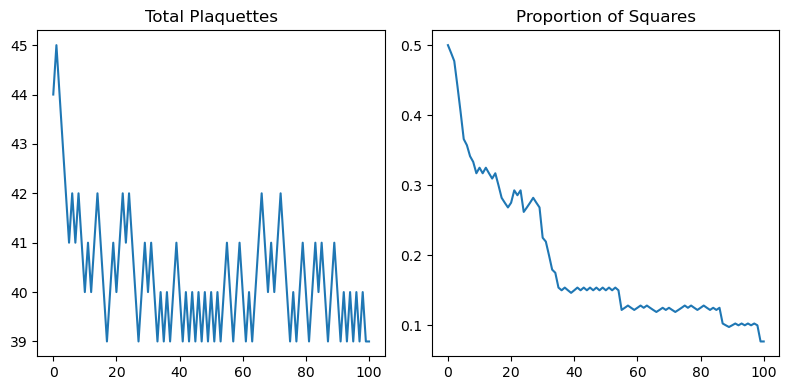

In [9]:
with open(f"lattices/0100_6675.pkl", "rb") as f:
    data = pickle.load(f)
all_lattices = data["lattices"]
energies = data["energies"]
total_plaqs = data["total_plaqs"]
n_squares = data["n_squares"]
params = data["params"]

proportion_squares = np.array(n_squares) / np.array(total_plaqs)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].plot(total_plaqs)
ax[1].plot(proportion_squares)

ax[0].set_title("Total Plaquettes")
ax[1].set_title("Proportion of Squares")
plt.tight_layout()
# plt.savefig("pachner_metropolis_energy.png", dpi=300)

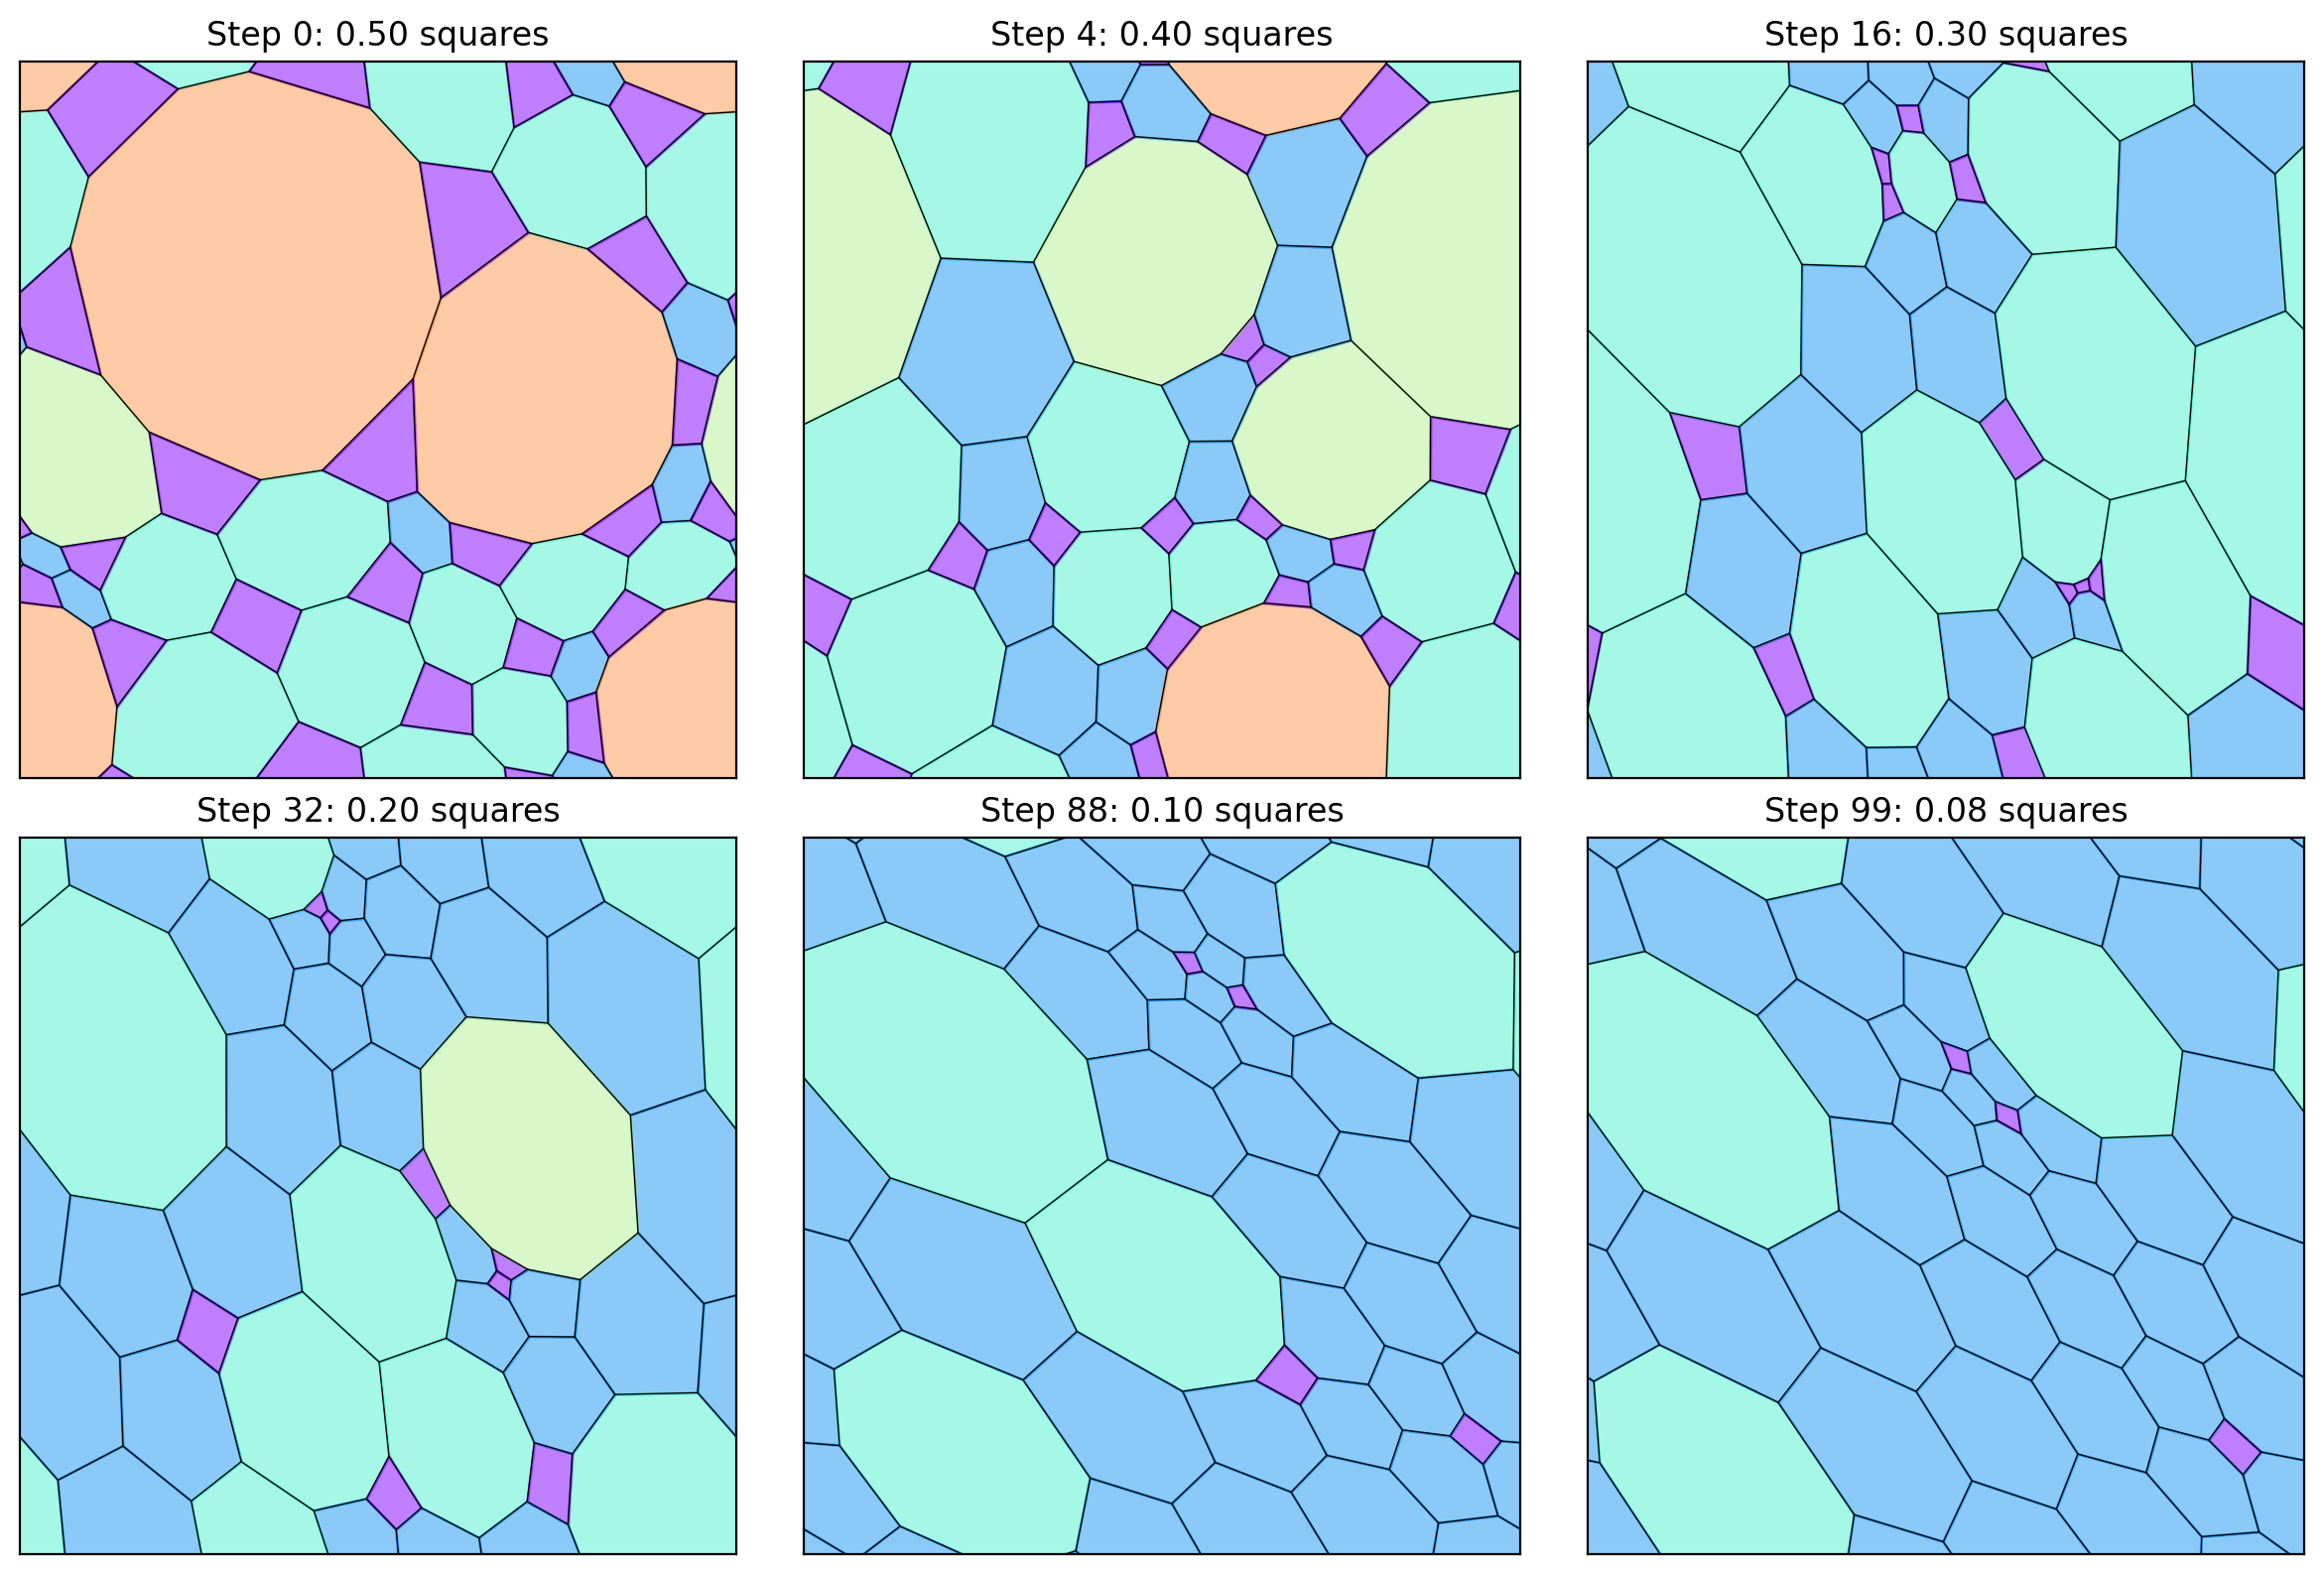

In [10]:
cmap = plt.get_cmap("rainbow")
max_sides = 10


n_squares_to_consider = np.linspace(0.5, 0, 6)
lattices_to_look_at = np.array(
    [np.argmin(np.abs(proportion_squares - val)) for val in n_squares_to_consider]
)

scale = 4
cols = np.ceil(len(lattices_to_look_at) / 2).astype(int)
fig, ax = plt.subplots(2, cols, figsize=(scale * cols, scale * 2), dpi=200)
ax = ax.flatten()

for i, idx in enumerate(lattices_to_look_at):
    l = Lattice(*all_lattices[idx])
    pl.plot_edges(l, ax=ax[i], linewidth=0.5)

    sides = np.array([p.n_sides for p in l.plaquettes]) - 4
    s = sides / max_sides
    color_scheme = cmap(s)
    pl.plot_plaquettes(
        l, ax=ax[i], labels=np.arange(len(sides)), color_scheme=color_scheme, alpha=0.5
    )

    ax[i].set_aspect("equal")
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    ax[i].set_title(f"Step {idx}: {proportion_squares[idx]:.2f} squares")

plt.tight_layout()
plt.savefig("pachner_metropolis_lattices.png", dpi=300)